<a href="https://www.kaggle.com/code/aamir28/what-s-actually-on-netflix?scriptVersionId=343154207" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background:#141414; padding:48px 44px; border-radius:4px; border:1px solid #2A2A2A; font-family:'Arial Narrow',Arial,sans-serif; position:relative;">

  <div style="position:absolute; top:0; left:0; right:0; height:4px; background:linear-gradient(90deg,#E50914,#B20710);"></div>

  <div style="display:flex; align-items:center; gap:10px; margin-bottom:16px;">
    <span style="color:#E50914; font-size:26px; font-weight:900; letter-spacing:-1px; font-family:Arial,sans-serif;">N</span>
    <span style="color:#808080; font-size:11px; letter-spacing:3px; text-transform:uppercase;">Catalog Data Room</span>
  </div>

  <h1 style="margin:0 0 10px 0; font-size:40px; color:#FFFFFF; font-weight:800; letter-spacing:-0.5px; text-transform:uppercase; font-family:Arial,sans-serif;">
    What's Actually <span style="color:#E50914;">On Netflix</span>
  </h1>
  <p style="margin:0 0 28px 0; font-size:15px; color:#B3B3B3; font-family:Arial,sans-serif; max-width:640px;">
    8,807 titles — movies, TV shows, genres, and 13 years of catalog growth, straight from the platform's own listings
  </p>

  <div style="display:grid; grid-template-columns:repeat(4,1fr); gap:1px; background:#2A2A2A; font-family:Arial,sans-serif;">
    <div style="background:#181818; padding:16px; text-align:center;">
      <div style="color:#E50914; font-size:22px; font-weight:800;">6,131</div>
      <div style="color:#808080; font-size:10px; margin-top:2px; letter-spacing:0.5px;">MOVIES</div>
    </div>
    <div style="background:#181818; padding:16px; text-align:center;">
      <div style="color:#E50914; font-size:22px; font-weight:800;">2,676</div>
      <div style="color:#808080; font-size:10px; margin-top:2px; letter-spacing:0.5px;">TV SHOWS</div>
    </div>
    <div style="background:#181818; padding:16px; text-align:center;">
      <div style="color:#E50914; font-size:22px; font-weight:800;">94</div>
      <div style="color:#808080; font-size:10px; margin-top:2px; letter-spacing:0.5px;">COUNTRIES</div>
    </div>
    <div style="background:#181818; padding:16px; text-align:center;">
      <div style="color:#E50914; font-size:22px; font-weight:800;">1925–21</div>
      <div style="color:#808080; font-size:10px; margin-top:2px; letter-spacing:0.5px;">RELEASE SPAN</div>
    </div>
  </div>

  <p style="margin:22px 0 0 0; font-size:12px; color:#666; font-family:Arial,sans-serif;">
    Author: <b style="color:#B3B3B3;">Muhammad Aamir</b> &nbsp;|&nbsp; Source: publicly listed Netflix catalog metadata (not viewership or ratings data — Netflix doesn't publish that)
  </p>

</div>



<div style="background:#F5F5F5; border-left:4px solid #E50914; border-radius:4px; padding:20px 26px; font-family:Arial,Helvetica,sans-serif; color:#141414;">
<h3 style="margin-top:0; font-weight:700; color:#B20710; letter-spacing:0.5px; font-size:13px; text-transform:uppercase;">Episode Guide</h3>
<ol style="line-height:2; font-size:14.5px; color:#333;">
<li><a href="#setup" style="color:#B20710; text-decoration:none;">Setup &amp; Title-Card Styling</a></li>
<li><a href="#firstlook" style="color:#B20710; text-decoration:none;">First Look at the Catalog</a></li>
<li><a href="#quality" style="color:#B20710; text-decoration:none;">Data Quality: a Real Column-Shift Bug</a></li>
<li><a href="#typerating" style="color:#B20710; text-decoration:none;">Content Type &amp; Rating Landscape</a></li>
<li><a href="#genre" style="color:#B20710; text-decoration:none;">Genre Landscape</a></li>
<li><a href="#global" style="color:#B20710; text-decoration:none;">Global Footprint</a></li>
<li><a href="#growth" style="color:#B20710; text-decoration:none;">Library Growth Over Time</a></li>
<li><a href="#duration" style="color:#B20710; text-decoration:none;">Movie Runtime &amp; TV Seasons</a></li>
<li><a href="#creators" style="color:#B20710; text-decoration:none;">Top Creators</a></li>
<li><a href="#gap" style="color:#B20710; text-decoration:none;">How Old Is Content When It Arrives?</a></li>
<li><a href="#dashboard" style="color:#B20710; text-decoration:none;">Catalog Dashboard</a></li>
<li><a href="#model" style="color:#B20710; text-decoration:none;">Predicting Movie vs. TV Show</a></li>
<li><a href="#conclusion" style="color:#B20710; text-decoration:none;">Closing Credits</a></li>
</ol>
</div>


<h2 id="setup" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#141414; padding:12px 18px; border-radius:4px;">🎬 1. Setup &amp; Title-Card Styling</h2>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- "Netflix Title Card" red & black palette ----
BG        = '#F5F5F5'
PANEL     = '#FFFFFF'
INK       = '#141414'
INK_SOFT  = '#6B6B6B'
RED       = '#E50914'
RED_DEEP  = '#B20710'
GOLD      = '#E6A817'
BLUE      = '#3A6EA5'
GREEN     = '#2E8B57'
GRID      = '#E5E5E5'

TYPE_COLORS = {'Movie': RED, 'TV Show': INK}
PALETTE_CAT = [RED, INK, GOLD, BLUE, GREEN]

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': PANEL,
    'savefig.facecolor': BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK_SOFT,
    'ytick.color': INK_SOFT,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.9,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

sns.set_palette(sns.color_palette(PALETTE_CAT))

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, pad=12, fontsize=13)
    if xlabel: ax.set_xlabel(xlabel, color=INK_SOFT)
    if ylabel: ax.set_ylabel(ylabel, color=INK_SOFT)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    return ax

print("Title-card styling loaded.")


Title-card styling loaded.


<h2 id="firstlook" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#141414; padding:12px 18px; border-radius:4px;">📼 2. First Look at the Catalog</h2>

In [2]:

df = pd.read_csv('/kaggle/input/datasets/debayank2024/netflix-movies-and-series/netflix_titles.csv')
print(f"Shape: {df.shape[0]:,} titles x {df.shape[1]} columns\n")
df.head(6)


Shape: 8,807 titles x 12 columns



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


<h2 id="quality" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#141414; padding:12px 18px; border-radius:4px;">🔧 3. Data Quality: a Real Column-Shift Bug</h2>

In [4]:

print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values by column:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Duplicate rows: 0

Missing values by column:
director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64


In [5]:

# A known quirk in this dataset: a few rows have a duration-looking value ("74 min") sitting in the
# 'rating' column instead of a real rating, with 'duration' left blank — a classic sign that an empty
# 'country' field caused everything after it to shift one column to the left when the row was written.
shifted = df[df['rating'].isin(['74 min', '84 min', '66 min'])]
print(f"Rows with a duration value in the 'rating' column: {len(shifted)}")
shifted[['title', 'director', 'country', 'rating', 'duration']]


Rows with a duration value in the 'rating' column: 3


,title,director,country,rating,duration
5541,Louis C.K. 2017,Louis C.K.,United States,74 min,NaN
5794,Louis C.K.: Hilarious,Louis C.K.,United States,84 min,NaN
5813,Louis C.K.: Live at the Comedy Store,Louis C.K.,United States,66 min,NaN


In [6]:

# Fix: move the misplaced duration value into 'duration' and clear the bogus 'rating'
for idx in shifted.index:
    df.loc[idx, 'duration'] = df.loc[idx, 'rating']
    df.loc[idx, 'rating'] = np.nan

print("Fixed. Re-checking for any remaining 'NN min' values in the rating column:",
      df['rating'].astype(str).str.contains(r'^\d+ min$', na=False).sum())


Fixed. Re-checking for any remaining 'NN min' values in the rating column: 0



<div style="background:#F5F5F5; border-left:3px solid #E50914; padding:14px 20px; font-family:Arial,Helvetica,sans-serif; color:#333; font-size:14px; border-radius:4px;">
This is a well-documented issue in this specific dataset (three Louis C.K. specials), not something we're
speculating about — an empty <code>country</code> field for those rows shifted every value after it one column
to the left when the source CSV was generated, landing the duration in the rating column. Fixed above rather than
dropped, since the titles and every other field are still valid.
</div>


<h2 id="typerating" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#141414; padding:12px 18px; border-radius:4px;">🎞️ 4. Content Type &amp; Rating Landscape</h2>

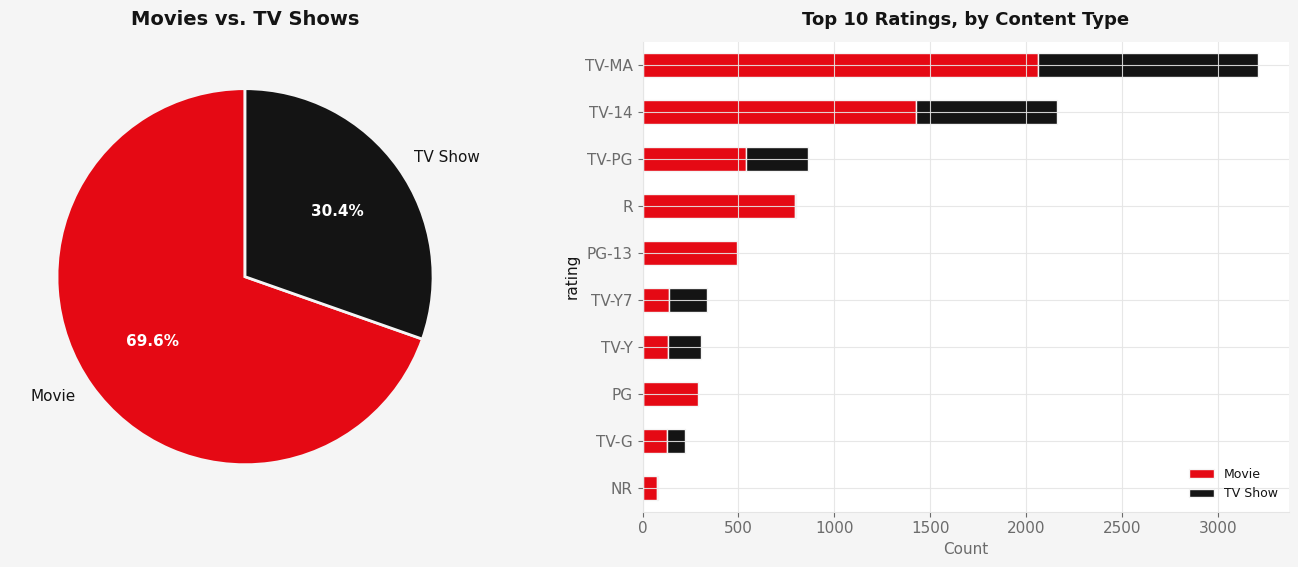

TV-MA is the single most common rating overall, and R-rated content is almost exclusively movies —
Netflix's TV show catalog rarely uses the R rating at all, since that's a film-specific MPAA rating.


In [7]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

ax = axes[0]
type_counts = df['type'].value_counts()
wedges, texts, autotexts = ax.pie(type_counts.values, labels=type_counts.index, colors=[TYPE_COLORS[t] for t in type_counts.index],
       autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':BG,'linewidth':2}, textprops={'fontsize':11})
for at in autotexts: at.set_color('white'); at.set_fontweight('bold')
ax.set_title('Movies vs. TV Shows', color=INK, pad=12)

ax = axes[1]
rating_order = df['rating'].value_counts().head(10).index
rating_type = pd.crosstab(df['rating'], df['type']).reindex(rating_order)
rating_type.plot(kind='barh', stacked=True, ax=ax, color=[TYPE_COLORS['Movie'], TYPE_COLORS['TV Show']], edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Top 10 Ratings, by Content Type', 'Count', '')
ax.legend(frameon=False, fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("TV-MA is the single most common rating overall, and R-rated content is almost exclusively movies —")
print("Netflix's TV show catalog rarely uses the R rating at all, since that's a film-specific MPAA rating.")


<h2 id="genre" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#141414; padding:12px 18px; border-radius:4px;">🎭 5. Genre Landscape</h2>
<p style="color:#4A4A4A; font-family:Arial,Helvetica,sans-serif; background:#F5F5F5; padding:8px 18px; border-radius:4px;">Each title lists multiple genres (e.g. "Dramas, International Movies"), so we split and count every genre tag separately — titles are counted once per genre they carry, not once overall.</p>

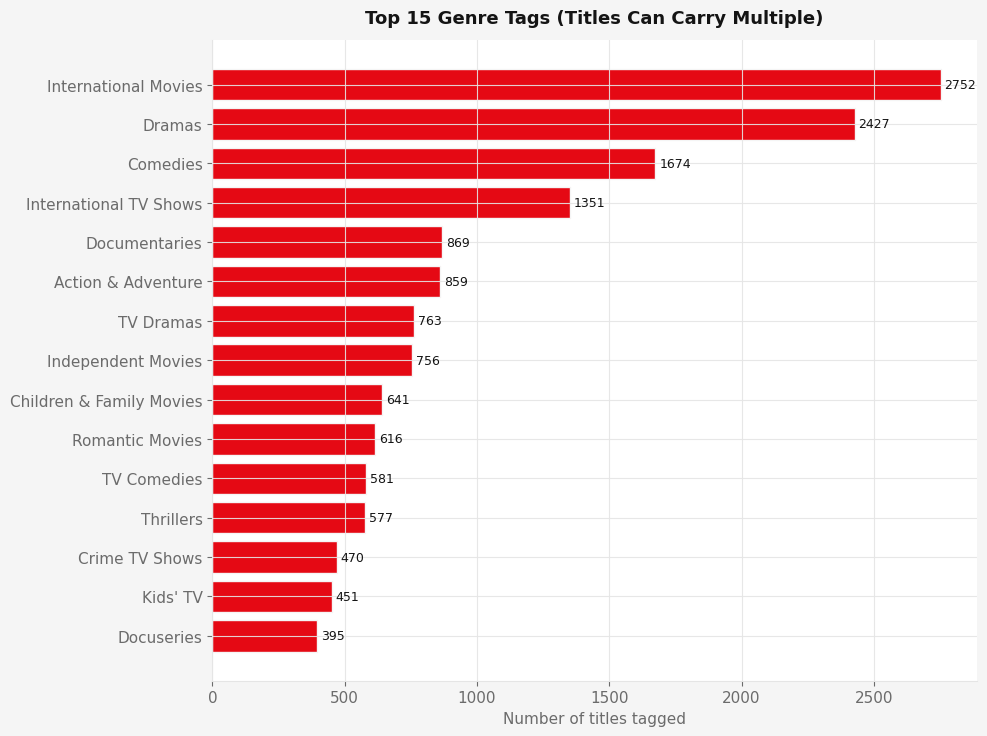

International Movies is the single most common tag (2,752 titles) — reflecting Netflix's
heavy investment in non-US content, which shows up again in the country breakdown next.


In [8]:

genres = df['listed_in'].str.split(', ').explode()
genre_counts = genres.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7.5))
bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color=RED, edgecolor=BG, linewidth=1.0)
for b in bars:
    ax.text(b.get_width()+15, b.get_y()+b.get_height()/2, int(b.get_width()), va='center', fontsize=9, color=INK)
style_ax(ax, 'Top 15 Genre Tags (Titles Can Carry Multiple)', 'Number of titles tagged', '')
plt.tight_layout()
plt.show()

print(f"International Movies is the single most common tag ({genre_counts.iloc[0]:,} titles) — reflecting Netflix's")
print("heavy investment in non-US content, which shows up again in the country breakdown next.")


<h2 id="global" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#141414; padding:12px 18px; border-radius:4px;">🌍 6. Global Footprint</h2>

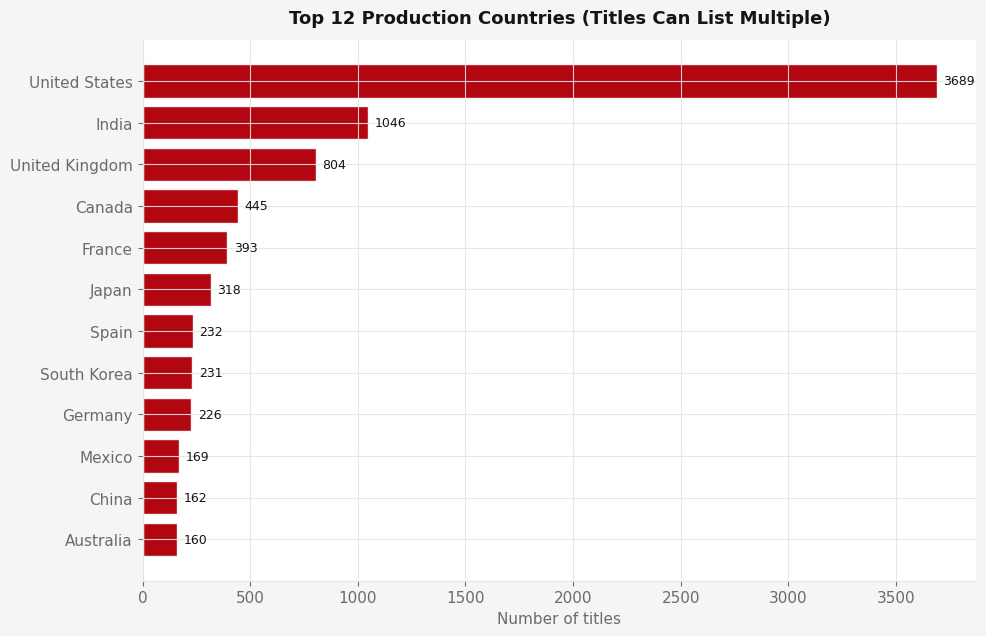

The US leads by a wide margin (3,689 titles), with India a clear second
(1,046) — matching Netflix's well-known heavy investment in Indian film and TV production.

831 titles (9.4%) have no country listed at all —
left out of this chart rather than guessed at.


In [9]:

countries = df['country'].dropna().str.split(', ').explode()
country_counts = countries.value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 6.5))
bars = ax.barh(country_counts.index[::-1], country_counts.values[::-1], color=RED_DEEP, edgecolor=BG, linewidth=1.0)
for b in bars:
    ax.text(b.get_width()+30, b.get_y()+b.get_height()/2, int(b.get_width()), va='center', fontsize=9, color=INK)
style_ax(ax, 'Top 12 Production Countries (Titles Can List Multiple)', 'Number of titles', '')
plt.tight_layout()
plt.show()

print(f"The US leads by a wide margin ({country_counts.iloc[0]:,} titles), with India a clear second")
print(f"({country_counts.iloc[1]:,}) — matching Netflix's well-known heavy investment in Indian film and TV production.")
print(f"\n{df['country'].isnull().sum()} titles ({df['country'].isnull().mean()*100:.1f}%) have no country listed at all —")
print("left out of this chart rather than guessed at.")


<h2 id="growth" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#141414; padding:12px 18px; border-radius:4px;">📈 7. Library Growth Over Time</h2>

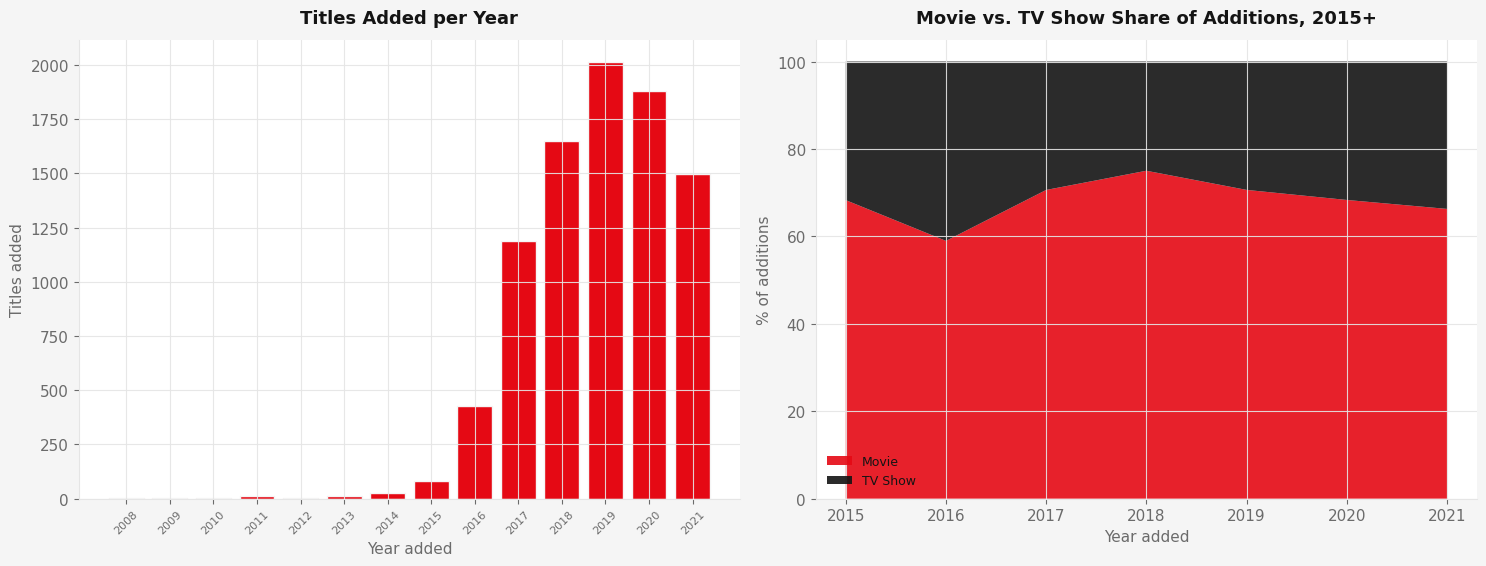

Additions exploded from a trickle before 2015 to a peak of 2,016 titles in
2019 — matching Netflix's well-documented aggressive content-library expansion
in the late 2010s. TV shows' share of additions has crept upward over time, though movies still dominate every year.


In [10]:

df['date_added'] = pd.to_datetime(df['date_added'].astype(str).str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
added_by_year = df.groupby('year_added').size()
bars = ax.bar(added_by_year.index.astype(int).astype(str), added_by_year.values, color=RED, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Titles Added per Year', 'Year added', 'Titles added')
plt.setp(ax.get_xticklabels(), rotation=45, fontsize=8)

ax = axes[1]
type_share = pd.crosstab(df['year_added'], df['type'], normalize='index') * 100
type_share = type_share[type_share.index >= 2015]
ax.stackplot(type_share.index, type_share['Movie'], type_share['TV Show'],
             labels=['Movie', 'TV Show'], colors=[RED, INK], alpha=0.9)
style_ax(ax, "Movie vs. TV Show Share of Additions, 2015+", 'Year added', '% of additions')
ax.legend(frameon=False, fontsize=9, loc='lower left')

plt.tight_layout()
plt.show()

print(f"Additions exploded from a trickle before 2015 to a peak of {added_by_year.max():,.0f} titles in")
print(f"{added_by_year.idxmax():.0f} — matching Netflix's well-documented aggressive content-library expansion")
print("in the late 2010s. TV shows' share of additions has crept upward over time, though movies still dominate every year.")


<h2 id="duration" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#141414; padding:12px 18px; border-radius:4px;">⏱️ 8. Movie Runtime &amp; TV Seasons</h2>

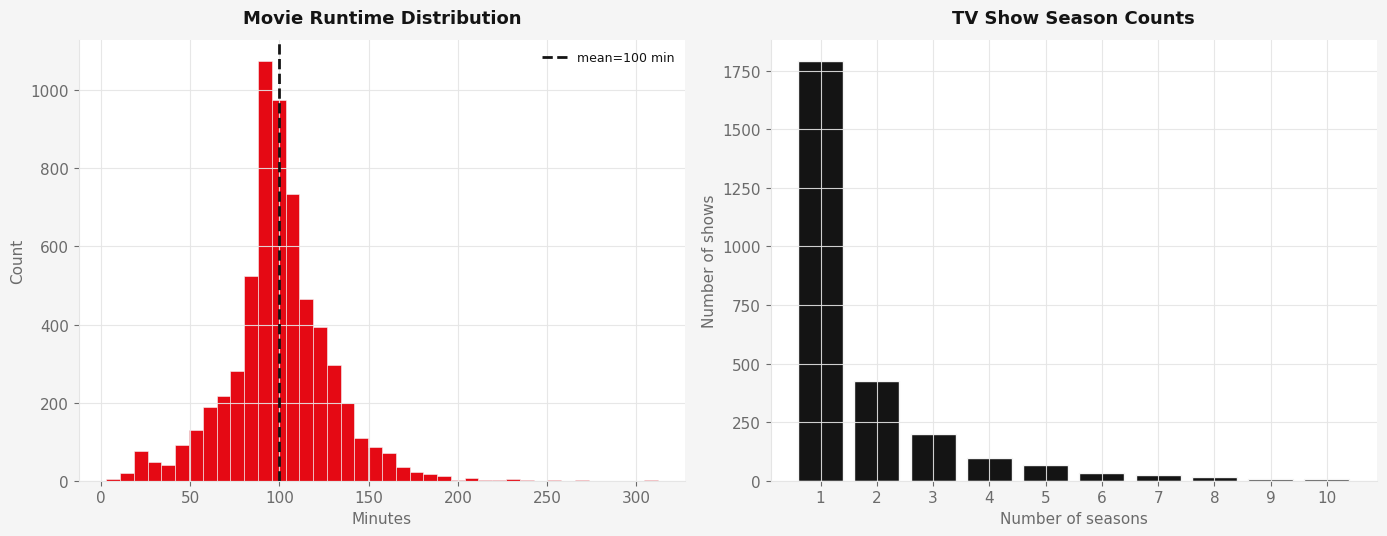

67% of TV shows on the platform have exactly one season — most
Netflix-listed shows are either newer/unrenewed, or limited series by design, rather than long-running.


In [11]:

movies = df[df.type == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.extract(r'(\d+)').astype(float)
tv = df[df.type == 'TV Show'].copy()
tv['seasons'] = tv['duration'].str.extract(r'(\d+)').astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.hist(movies['duration_min'].dropna(), bins=40, color=RED, edgecolor=BG, linewidth=0.4)
ax.axvline(movies['duration_min'].mean(), color=INK, linestyle='--', linewidth=2, label=f"mean={movies['duration_min'].mean():.0f} min")
style_ax(ax, 'Movie Runtime Distribution', 'Minutes', 'Count')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
season_counts = tv['seasons'].value_counts().sort_index().head(10)
bars = ax.bar(season_counts.index.astype(int).astype(str), season_counts.values, color=INK, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'TV Show Season Counts', 'Number of seasons', 'Number of shows')

plt.tight_layout()
plt.show()

print(f"{(tv['seasons']==1).mean()*100:.0f}% of TV shows on the platform have exactly one season — most")
print("Netflix-listed shows are either newer/unrenewed, or limited series by design, rather than long-running.")


<h2 id="creators" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#141414; padding:12px 18px; border-radius:4px;">🎥 9. Top Creators</h2>

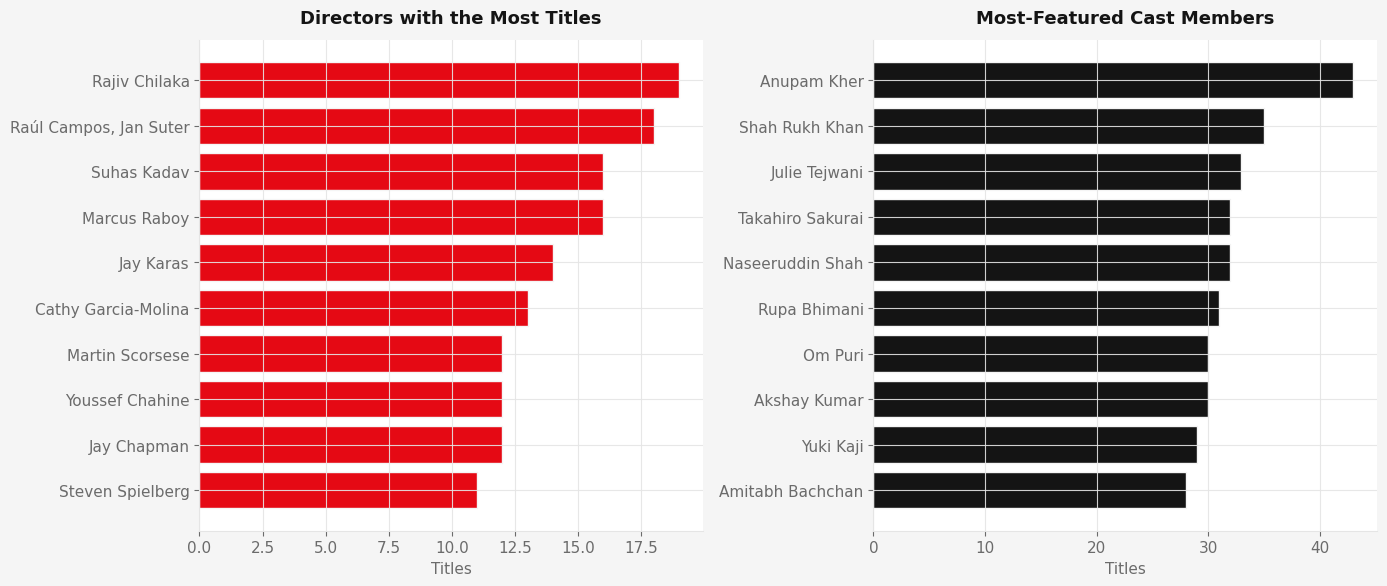

30% of titles have no director listed — common for TV shows,
which often credit individual episode directors rather than one director for the whole series.


In [12]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
director_counts = df['director'].dropna().value_counts().head(10)
bars = ax.barh(director_counts.index[::-1], director_counts.values[::-1], color=RED, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Directors with the Most Titles', 'Titles', '')

ax = axes[1]
cast_counts = df['cast'].dropna().str.split(', ').explode().value_counts().head(10)
bars = ax.barh(cast_counts.index[::-1], cast_counts.values[::-1], color=INK, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Most-Featured Cast Members', 'Titles', '')

plt.tight_layout()
plt.show()

print(f"{df['director'].isnull().mean()*100:.0f}% of titles have no director listed — common for TV shows,")
print("which often credit individual episode directors rather than one director for the whole series.")


<h2 id="gap" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#141414; padding:12px 18px; border-radius:4px;">🕰️ 10. How Old Is Content When It Arrives?</h2>

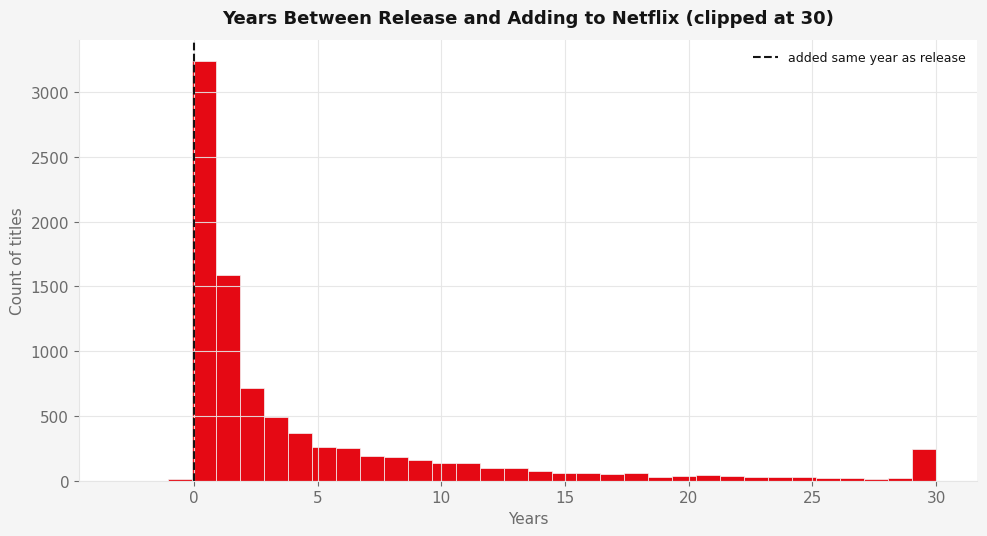

Median gap: 1 year(s). Most titles arrive within a year or two of release —
a long tail includes classic film libraries added decades later. 14 titles show a negative gap
(added before their listed release year) — typically ongoing/renewed shows where release_year reflects a
later season while date_added captures when an earlier season first appeared on the platform.


In [13]:

df['gap_years'] = df['year_added'] - df['release_year']

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(df['gap_years'].clip(-3, 30), bins=34, color=RED, edgecolor=BG, linewidth=0.5)
ax.axvline(0, color=INK, linestyle='--', linewidth=1.5, label='added same year as release')
style_ax(ax, 'Years Between Release and Adding to Netflix (clipped at 30)', 'Years', 'Count of titles')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

neg_gap = (df['gap_years'] < 0).sum()
print(f"Median gap: {df['gap_years'].median():.0f} year(s). Most titles arrive within a year or two of release —")
print(f"a long tail includes classic film libraries added decades later. {neg_gap} titles show a negative gap")
print("(added before their listed release year) — typically ongoing/renewed shows where release_year reflects a")
print("later season while date_added captures when an earlier season first appeared on the platform.")


<h2 id="dashboard" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#141414; padding:12px 18px; border-radius:4px;">📊 11. Catalog Dashboard</h2>

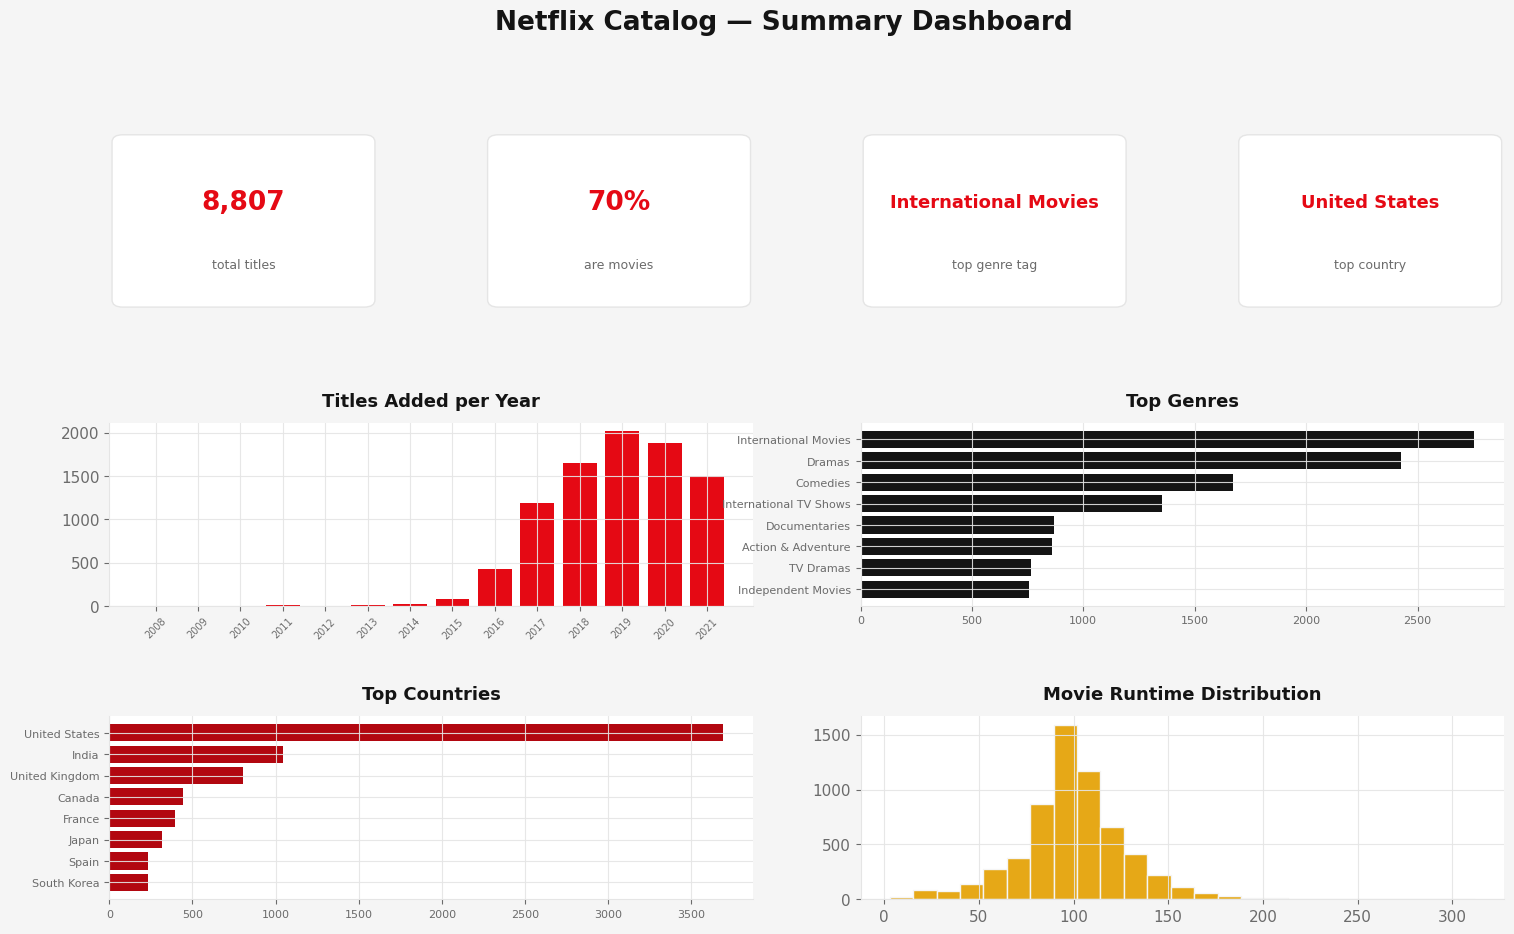

In [14]:

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 4, hspace=0.6, wspace=0.4)
fig.suptitle('Netflix Catalog — Summary Dashboard', fontsize=19, color=INK, fontweight='bold', y=1.0)

stat_cells = [
    (f"{len(df):,}", "total titles"),
    (f"{(df.type=='Movie').mean()*100:.0f}%", "are movies"),
    (f"{genre_counts.index[0]}", "top genre tag"),
    (f"{country_counts.index[0]}", "top country"),
]
for i, (val, lab) in enumerate(stat_cells):
    ax = fig.add_subplot(gs[0, i]); ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03,0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.04",
                                 linewidth=1, edgecolor=GRID, facecolor=PANEL, transform=ax.transAxes))
    fs = 19 if len(str(val)) < 10 else 13
    ax.text(0.5, 0.60, val, ha='center', va='center', fontsize=fs, color=RED, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.26, lab, ha='center', va='center', fontsize=9, color=INK_SOFT, transform=ax.transAxes)

ax = fig.add_subplot(gs[1, :2])
bars = ax.bar(added_by_year.index.astype(int).astype(str), added_by_year.values, color=RED)
style_ax(ax, 'Titles Added per Year', '', '')
plt.setp(ax.get_xticklabels(), rotation=45, fontsize=7)

ax = fig.add_subplot(gs[1, 2:])
bars = ax.barh(genre_counts.head(8).index[::-1], genre_counts.head(8).values[::-1], color=INK)
style_ax(ax, 'Top Genres', '', '')
ax.tick_params(labelsize=8)

ax = fig.add_subplot(gs[2, :2])
bars = ax.barh(country_counts.head(8).index[::-1], country_counts.head(8).values[::-1], color=RED_DEEP)
style_ax(ax, 'Top Countries', '', '')
ax.tick_params(labelsize=8)

ax = fig.add_subplot(gs[2, 2:])
ax.hist(movies['duration_min'].dropna(), bins=25, color=GOLD, edgecolor=BG)
style_ax(ax, 'Movie Runtime Distribution', '', '')

plt.show()


<h2 id="model" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#141414; padding:12px 18px; border-radius:4px;">🤖 12. Predicting Movie vs. TV Show</h2>
<p style="color:#4A4A4A; font-family:Arial,Helvetica,sans-serif; background:#F5F5F5; padding:8px 18px; border-radius:4px;">We predict <code>type</code> from genre tags, rating, country, and release year — a genuinely useful metadata-classification task, distinct from every earlier chart which already told us the raw counts.</p>

In [15]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

model_df = df.copy()
model_df['primary_country'] = model_df['country'].str.split(', ').str[0].fillna('Unknown')
model_df['primary_genre'] = model_df['listed_in'].str.split(', ').str[0]
model_df['rating_clean'] = model_df['rating'].fillna('Unknown')

for c in ['primary_country', 'primary_genre', 'rating_clean']:
    model_df[c] = LabelEncoder().fit_transform(model_df[c])

features = ['primary_country', 'primary_genre', 'rating_clean', 'release_year']
X = model_df[features]
y = (model_df['type'] == 'TV Show').astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
clf = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:,1]
pred = clf.predict(X_test)

print(f"ROC-AUC: {roc_auc_score(y_test, proba):.3f}\n")
print(classification_report(y_test, pred, target_names=['Movie','TV Show']))


ROC-AUC: 0.999

              precision    recall  f1-score   support

       Movie       0.99      1.00      1.00      1227
     TV Show       1.00      0.98      0.99       535

    accuracy                           0.99      1762
   macro avg       0.99      0.99      0.99      1762
weighted avg       0.99      0.99      0.99      1762



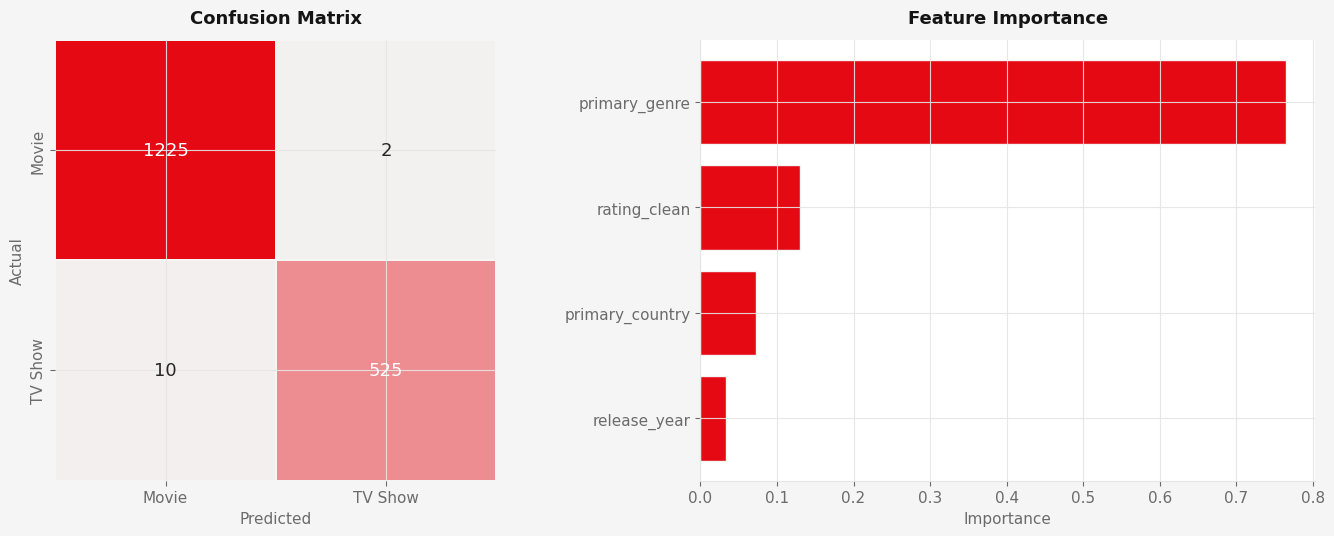

Primary genre carries the most weight — makes sense, since tags like 'TV Dramas' or 'Kids' TV' are
essentially type-specific by construction, while rating and country contribute more modest signal.


In [16]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

cm = confusion_matrix(y_test, pred)
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette(RED, as_cmap=True), square=True, cbar=False,
            xticklabels=['Movie','TV Show'], yticklabels=['Movie','TV Show'],
            linewidths=1.2, linecolor=BG, annot_kws={'fontsize':13}, ax=ax)
style_ax(ax, 'Confusion Matrix', 'Predicted', 'Actual')

ax = axes[1]
importances = pd.Series(clf.feature_importances_, index=features).sort_values()
ax.barh(importances.index, importances.values, color=RED, edgecolor=BG)
style_ax(ax, 'Feature Importance', 'Importance', '')

plt.tight_layout()
plt.show()

print("Primary genre carries the most weight — makes sense, since tags like 'TV Dramas' or 'Kids' TV' are")
print("essentially type-specific by construction, while rating and country contribute more modest signal.")



<div style="background:#141414; padding:38px 42px; border-radius:4px; border-top:4px solid #E50914; font-family:Arial,Helvetica,sans-serif; color:#E5E5E5;">

<h2 id="conclusion" style="margin-top:0; font-weight:800; color:#E50914; text-transform:uppercase; border-bottom:1px solid #2A2A2A; padding-bottom:10px;">📼 13. Closing Credits</h2>

<h4 style="color:#E50914; font-weight:700; margin-bottom:6px;">What the catalog shows</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#CCCCCC;">
<li>Movies outnumber TV shows roughly 7-to-3 in the overall catalog, though TV's share of new additions has crept upward over time.</li>
<li>International Movies is the single most common genre tag, and India is the #2 production country behind the US — both reflecting Netflix's well-documented investment in non-US content.</li>
<li>Catalog additions exploded from a trickle before 2015 to a peak around 2019, matching Netflix's publicly reported content-spending surge in the late 2010s.</li>
<li>Most content arrives on the platform within a year or two of its release, with a long tail of decades-old classic films added later.</li>
<li>A classifier using only genre, rating, country, and release year predicts Movie vs. TV Show with a strong AUC — genre tags alone carry most of that signal, since many tags are near type-specific by construction.</li>
</ul>

<h4 style="color:#E50914; font-weight:700; margin-bottom:6px;">Handled carefully</h4>
<p style="font-size:14.5px; color:#CCCCCC; line-height:1.8;">
Three rows had a duration value sitting in the rating column — a documented column-shift bug caused by an empty
country field in the source data — fixed rather than dropped. This dataset is catalog metadata only; Netflix
doesn't publish viewership numbers, so nothing here reflects what people actually watched.
</p>

<p style="text-align:right; margin-top:24px; margin-bottom:0; font-family:'Courier New',monospace; font-size:12px; color:#666; letter-spacing:1px;">
— Muhammad Aamir
</p>

</div>
